## Librerías

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


## Datos

In [5]:
df = pd.read_csv("datos/datos_lab2.csv")
df["fecha"] = pd.to_datetime({
    "year": df["Año"],
    "month": df["Mes cod"],
    "day": 1 #utilizado por pd.to_datetime para crear una fecha completa (no se toma en cuenta)
})
df["Viajero"] = df["Viajero"].astype(int)
print(df.columns)

Index(['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región',
       'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia',
       'Tipo de Viajero', 'Viajero', 'fecha'],
      dtype='object')


## Series

In [6]:
# Serie total
serie_total = (
    df.groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)
serie_total.index.freq = "MS"

# Vías
serie_aerea = (
    df[df["Vía"] == "Aérea"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_terrestre = (
    df[df["Vía"] == "Terrestre"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_maritima = (
    df[df["Vía"] == "Marítima"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

# Top 3 regiones
top_regiones = (
    df.groupby("Región dos")["Viajero"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

reg1, reg2, reg3 = top_regiones.index

serie_region1 = (
    df[df["Región dos"] == reg1]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_region2 = (
    df[df["Región dos"] == reg2]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_region3 = (
    df[df["Región dos"] == reg3]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

## Lista de series para evaluar

In [7]:
series = {
    "Total": serie_total,
    "Aérea": serie_aerea,
    "Terrestre": serie_terrestre,
    "Marítima": serie_maritima,
    "Región 1": serie_region1,
    "Región 2": serie_region2,
    "Región 3": serie_region3,
}

## Elegir la serie a analizar

In [8]:
# serie = series["Total"]  # Cambiar a la serie deseada
# serie = series["Aérea"]
# serie = series["Terrestre"]
# serie = series["Marítima"]
# serie = series["Región 1"]
# serie = series["Región 2"]
serie = series["Región 3"]

## División de train y test

In [9]:
n_train = int(len(serie) * 0.7)

train = serie.iloc[:n_train]
test = serie.iloc[n_train:]

print(f"Entrenamiento: {len(train)} meses")
print(f"Prueba: {len(test)} meses")

Entrenamiento: 143 meses
Prueba: 62 meses


## Visualización de la serie

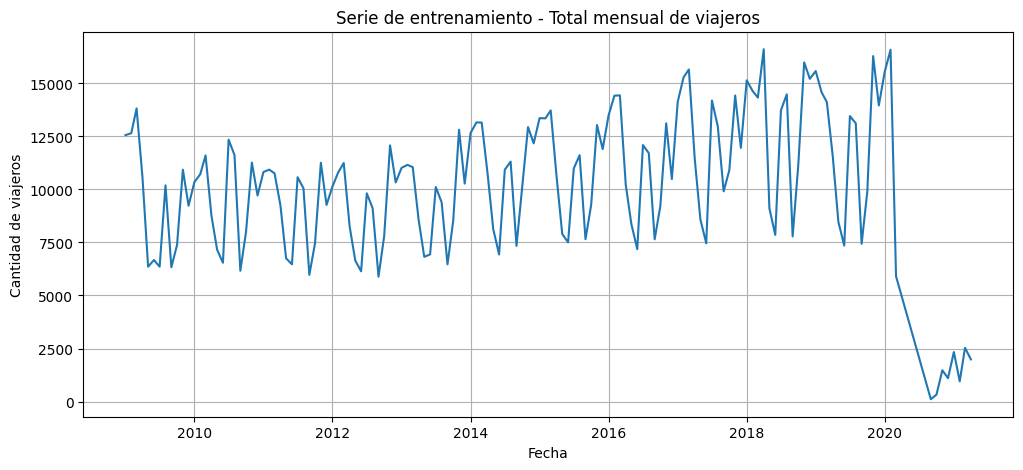

In [10]:
plt.figure(figsize=(12,5))

plt.plot(train)

plt.title("Serie de entrenamiento - Total mensual de viajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(True)

plt.show()

## Preparación para LSTM

In [ ]:
# Escalar los datos
scaler = MinMaxScaler()
train_escalado = scaler.fit_transform(train.values.reshape(-1, 1))
print(train_escalado[:5])
print(train_escalado.shape)
print(train_escalado.min())
print(train_escalado.max())

[[0.75452838]
 [0.76004119]
 [0.8309808 ]
 [0.63566972]
 [0.37862725]]
(143, 1)
0.0
1.0000000000000002


In [19]:
ventana = 12 # Tamaño de ventana para la serie temporal
x = []
y = []

for i in range(len(train_escalado) - ventana):
    x.append(train_escalado[i: i + ventana])
    y.append(train_escalado[i + ventana])

x = np.array(x)
y = np.array(y)

print(x.shape)
print(y.shape)

(131, 12, 1)
(131, 1)


## Modelo 1

In [27]:
modelo1 = Sequential()
modelo1.add(
    LSTM(
        units = 50, # Número de unidades LSTM
        input_shape = (ventana, 1) # Forma de entrada (ventana, 1)
    )
)

capa1 = Dense(units = 1) # Capa densa de salida
modelo1.add(capa1)

modelo1.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

historial = modelo1.fit(
    x, y, epochs=100, batch_size=32, verbose=1
)

modelo1.summary()

Epoch 1/100


c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5927  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3296 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1526 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0598 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0545 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0693 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0491 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0424 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0464 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0475 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0459 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0428 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0434 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0436 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0432 
Epoch 16/100
5/5 ━━━━━━━━━━━━━

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

## Predicción

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAE: 2943.393798828125
MSE: 13805909.0208425


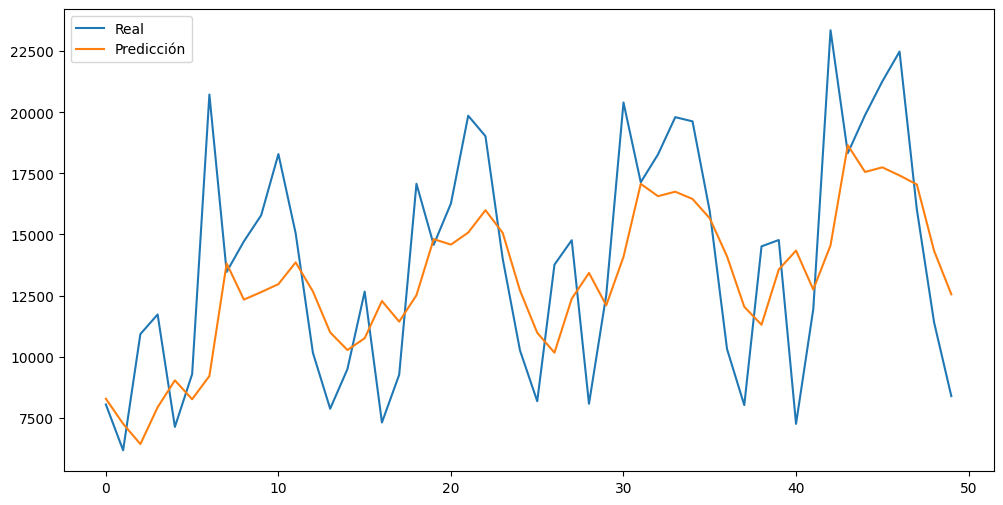

In [26]:
test_escalado = scaler.transform(test.values.reshape(-1, 1))
ventana = 12 # Tamaño de ventana para la serie temporal
x_test = []
y_test = []

for i in range(len(test_escalado) - ventana):
    x_test.append(test_escalado[i: i + ventana])
    y_test.append(test_escalado[i + ventana])

x_test = np.array(x_test)
y_test = np.array(y_test)

prediccion1 = modelo1.predict(x_test)
prediccion1 = scaler.inverse_transform(prediccion1)
y_real = scaler.inverse_transform(y_test)
mae = mean_absolute_error(y_real, prediccion1)
mse = mean_squared_error(y_real, prediccion1)

print("MAE:", mae)
print("MSE:", mse)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(y_real, label='Real')
plt.plot(prediccion1, label='Predicción')
plt.legend()
plt.show()


## Modelo 2

In [30]:
modelo2 = Sequential()
modelo2.add(
    LSTM(
        units = 100, # Número de unidades LSTM
        input_shape = (ventana, 1) # Forma de entrada (ventana, 1)
    )
)

capa1 = Dense(units = 1) # Capa densa de salida
modelo2.add(capa1)
dropout = Dropout(0.2)  # Capa de dropout para regularización
modelo2.add(dropout)

modelo2.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

historial2 = modelo2.fit(
    x, y, epochs=100, batch_size=32, verbose=1
)

modelo2.summary()

Epoch 1/100


c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2886  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1048 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1476 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1412 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1177 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1209 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1455 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1243 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1103 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1478 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1351 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1300 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1010 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1271 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1134 
Epoch 16/100
5/5 ━━━━━━━━━━━━━

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

## Predicción

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
MAE: 3748.618564453125
MSE: 21453909.053549476


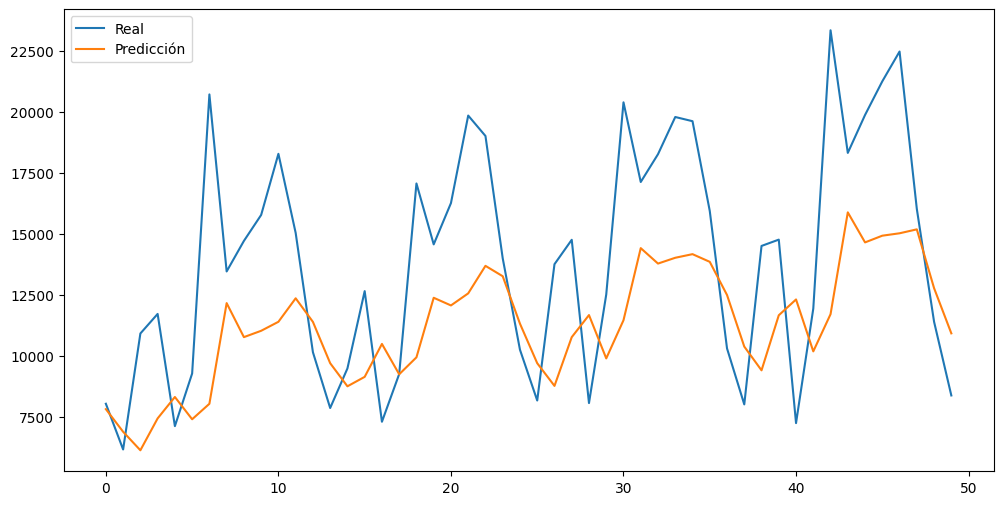

In [31]:
test_escalado = scaler.transform(test.values.reshape(-1, 1))
ventana = 12 # Tamaño de ventana para la serie temporal
x_test = []
y_test = []

for i in range(len(test_escalado) - ventana):
    x_test.append(test_escalado[i: i + ventana])
    y_test.append(test_escalado[i + ventana])

x_test = np.array(x_test)
y_test = np.array(y_test)

prediccion2 = modelo2.predict(x_test)
prediccion2 = scaler.inverse_transform(prediccion2)
y_real = scaler.inverse_transform(y_test)
mae = mean_absolute_error(y_real, prediccion2)
mse = mean_squared_error(y_real, prediccion2)

print("MAE:", mae)
print("MSE:", mse)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(y_real, label='Real')
plt.plot(prediccion2, label='Predicción')
plt.legend()
plt.show()
